In [5]:
import pandas as pd
import numpy as np
import importlib
import jenkspy
from tqdm import tqdm

from scipy.cluster.hierarchy import linkage, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from scipy.stats import energy_distance
import kmedoids


import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [6]:
df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs("individual", level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+"df_dist_w1_rolling_yearly_individual.csv", index_col=[0, 1])

In [7]:
df_cutoff = (
    pd.DataFrame({}, index=df_cs_yearly.index)
    .assign(
        total = df_cs_yearly.sum(axis=1),
        cutoff_5000 = lambda df: (df.total >= 5000).astype(int),
        cutoff_1000 = lambda df: (df.total >= 1000).astype(int),
    )
)

In [179]:
year = 2001

cutoff = 1000
param = "total"

country_idx = df_cutoff.xs(year, level=1).query(param+f" >= @cutoff").index.to_list()
df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]


df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_dist = df_dist_yearly.xs(year, level=1).loc[country_idx, country_idx]

np.fill_diagonal(df_dist.values, np.nan)

In [147]:
df_cs_example = df_cs
df_example = df_dist

In [183]:
D = df_example.fillna(0).values
condensed_D = squareform(D)

param_value = 0.2
method = "average"
param = "distance"

Z = linkage(condensed_D, method=method)
labels = fcluster(Z, t=param_value, criterion=param)

df_map = (
    pd.DataFrame(labels, index=df_example.index, columns=["cluster"])
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2")
    .merge(df_cs_example.sum(axis=1).to_frame("total_articles"), left_on="alpha-2", right_index=True)
)

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_example, labels))

Clusters: 
4    31
1    19
2    11
6    10
3     4
5     3
7     1
Name: count, dtype: int64

Silhouette Score:  0.30428815634649753
Dunn Index:  0.29065257662729566


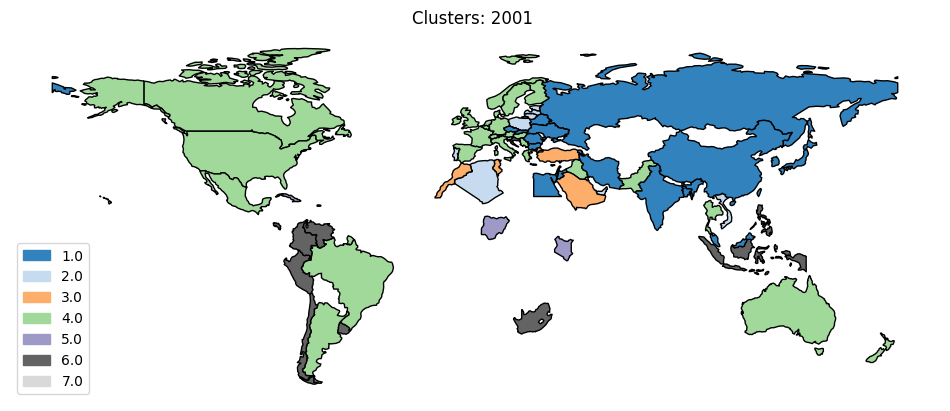

In [184]:
_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="alpha-3", title=f"Clusters: {year}")

In [150]:
country_labels = df_map.sort_values(["cluster", "total_articles"], ascending=[True, False])["alpha-2"].to_list()

uf.plotly_heatmap(
    df_example.loc[country_labels, country_labels],
    x_labels=country_labels,
    y_labels=country_labels,
    z_min=0, z_max=0.5,
    title=f"Distance between countries, {year}",
    x_type="country", y_type="country"
)

# Yearly analysis

In [185]:
# get raw mapping

start_year = 1970
end_year = 2023

subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_map_yearly_list = []
medoid_list = []

cutoff = 1000

# switch_years = {1998: 3}

silhouette_list = []
medoid_silhouette_list = []

for year_loop in range(start_year, end_year+1):
    country_idx = df_cutoff.xs(year_loop, level=1).query(f"total >= @cutoff").index.to_list()
    # df_cs = df_cs_yearly.xs(year, level=1).loc[country_idx]
    # country_idx = df_cs_roll_yearly.xs(year_loop, level=1).sum(axis=1).to_frame("total").query("total >= @cap_articles").index.to_list()
    
    df_dist_loop = (
        df_dist_yearly
        .xs(year_loop, level=1)
        .loc[country_idx, country_idx]
    )
    df_dist_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index]
    D_loop = df_dist_loop.loc[df_dist_loop.index, df_dist_loop.index].fillna(0).values
    
    if df_dist_loop.empty:
        continue
    # param_value = switch_years.get(year_loop, param_value)
    
    condensed_D = squareform(D_loop)

    param_value = 0.2
    method = "average"
    param = "distance"

    Z = linkage(condensed_D, method=method)
    labels = fcluster(Z, t=param_value, criterion=param)

    silhouette_list.append(silhouette_score(D_loop, labels, metric="precomputed"))

    df_map_yearly_list.append((
        pd.DataFrame(labels, index=df_dist_loop.index, columns=["cluster"])
        .assign(year=year_loop)
        .reset_index(names="country")
    ))

df_map_yearly = pd.concat(df_map_yearly_list)

# df_map_yearly.to_csv(uf.PATH+f"df_map_{param_value}_linkage_yearly_short_w1_{mode}.csv", index=False)

In [226]:
# clean clusters for all years

df_map_clean_yearly_list = []
df_map_prev = df_map_yearly.query("year == @start_year").drop(columns=["year"]).set_index("country")
for year_loop in range(start_year+1, end_year+1):
    
    df_map_cur = df_map_yearly.query("year == @year_loop").drop(columns=["year"]).set_index("country")
    # display(df_map_cur)
    # display(df_map_prev)

    df_map_cur_clean, df_medoids_cur_clean = uf.clean_clusters(df_map_cur, df_map_prev, fixed_country_list=["US", "RU", "CN", "ID"])
    df_map_clean_yearly_list.append(df_map_cur_clean.assign(year=year_loop).reset_index(names="country"))
    df_map_prev = df_map_cur_clean
df_map_clean_yearly = pd.concat(df_map_clean_yearly_list)

# df_map_clean_yearly.to_csv(uf.PATH+f"df_map_{param_value}_linkage_short_clean_yearly_w1_{mode}.csv", index=False)

In [227]:
df_cluster_prob_yearly_list = []

for year_loop in range(start_year, end_year+1):
    df_cs_loop = df_cs_yearly.xs(year, level=1)
    df_cluster_prob = uf.get_cluster_probabilities(df_map_clean_yearly.query("year==@year_loop"), df_cs_loop)
    df_cluster_prob_yearly_list.append(df_cluster_prob.assign(year=year_loop).reset_index(names="cluster"))
df_cluster_prob_yearly = pd.concat(df_cluster_prob_yearly_list)
# df_cluster_prob_yearly.to_csv(uf.PATH+f"df_prob_{param_value}_medoid_short_yearly_w1_{mode}.csv", index=False)

In [228]:
pivot = df_map_clean_yearly.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_dist_clusters_yearly = 1 - pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
) / (end_year - start_year)

df_n_years = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)
df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [229]:
df_stats_cluster = uf.get_cluster_stats(df_map_clean_yearly, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())

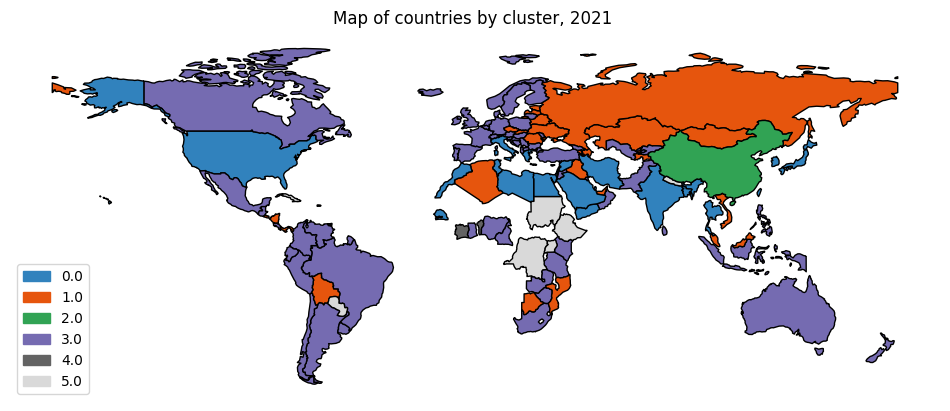

In [230]:
year = 2021

_, _ = uf.plot_map_discrete(
    df_map_clean_yearly.query("year==@year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    "cluster",
    title=f"Map of countries by cluster, {year}",
)

In [231]:
country_labels = (
    df_map_clean_yearly.query("year==@year")
    .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame("total"),
           left_on="country", right_index=True, how="left")
    .sort_values(["cluster", "total"], ascending=[True, False])["country"].to_list()
)

# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
# y_labels = df_dist.index.to_list()
uf.plotly_heatmap(
    df_dist_yearly.xs(year, level=1).loc[country_labels, country_labels],
    x_labels=country_labels,
    y_labels=country_labels,
    z_min=0, z_max=param_value*2,
    # colorscale="symmetrical",
    x_type="country",
    y_type="country",
    title=f"Distance between countries, {year}",
    line_height=10
)

In [258]:
df_map_clean_yearly

,country,cluster,year
0,AR,5,1974
1,AT,3,1974
2,AU,3,1974
3,BE,3,1974
4,BG,2,1974
...,...,...,...
123,VN,1,2023
124,YE,0,2023
125,ZA,4,2023
126,ZM,4,2023


In [264]:
df_cluster_prob_yearly = (
    df_cs_yearly
    .fillna(0)
    .merge(df_map_clean_yearly.set_index(["country", "year"]), left_index=True, right_index=True, how="right")
    .reset_index()
    .drop("country", axis=1)
    .groupby(["cluster", "year"])
    .sum()
)
df_cluster_prob_yearly = df_cluster_prob_yearly.div(df_cluster_prob_yearly.sum(axis=1), axis=0)

In [270]:
cluster = 3

df = df_cluster_prob_yearly.xs(cluster, level=0)

uf.plotly_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Probability distribution of subfields in cluster {cluster} over time",
    z_min=0, z_max=0.05, colorscale="non", line_height=10,
    x_type="subfield"
)

In [233]:
cluster1 = 0
cluster2 = 1

df0 = df_cluster_prob_yearly.query("cluster == @cluster1").drop(columns="cluster").set_index("year")
df1 = df_cluster_prob_yearly.query("cluster == @cluster2").drop(columns="cluster").set_index("year")

df = df0.sub(df1)

uf.plotly_heatmap(
    df, x_labels=df.columns, y_labels=df.index,
    title=f"Probability distribution of subfields in cluster {cluster1} minus cluster {cluster2} over time",
    z_min=-0.02, z_max=0.02, line_height=10,
    x_type="subfield"
)

In [234]:
df_stats_cluster

,year,cluster,country,countries_share,total_articles,total_articles_share,mean_distance,n_stayed
0,1974,2,2,0.009174,22455.0,0.023360,0.436963,NaN
1,1974,3,22,0.100917,902095.0,0.938462,0.321454,NaN
2,1974,4,4,0.018349,26250.0,0.027308,0.343090,NaN
3,1974,5,5,0.022936,10448.0,0.010869,0.348321,NaN
4,1975,0,26,0.119266,948146.0,0.946611,0.308034,NaN
...,...,...,...,...,...,...,...,...
274,2023,1,19,0.087156,1197697.0,0.063022,0.257372,NaN
275,2023,2,1,0.004587,3030783.0,0.159479,0.399192,1.0
276,2023,3,22,0.100917,1498156.0,0.078833,0.243795,21.0
277,2023,4,60,0.275229,6262671.0,0.329540,0.213484,NaN


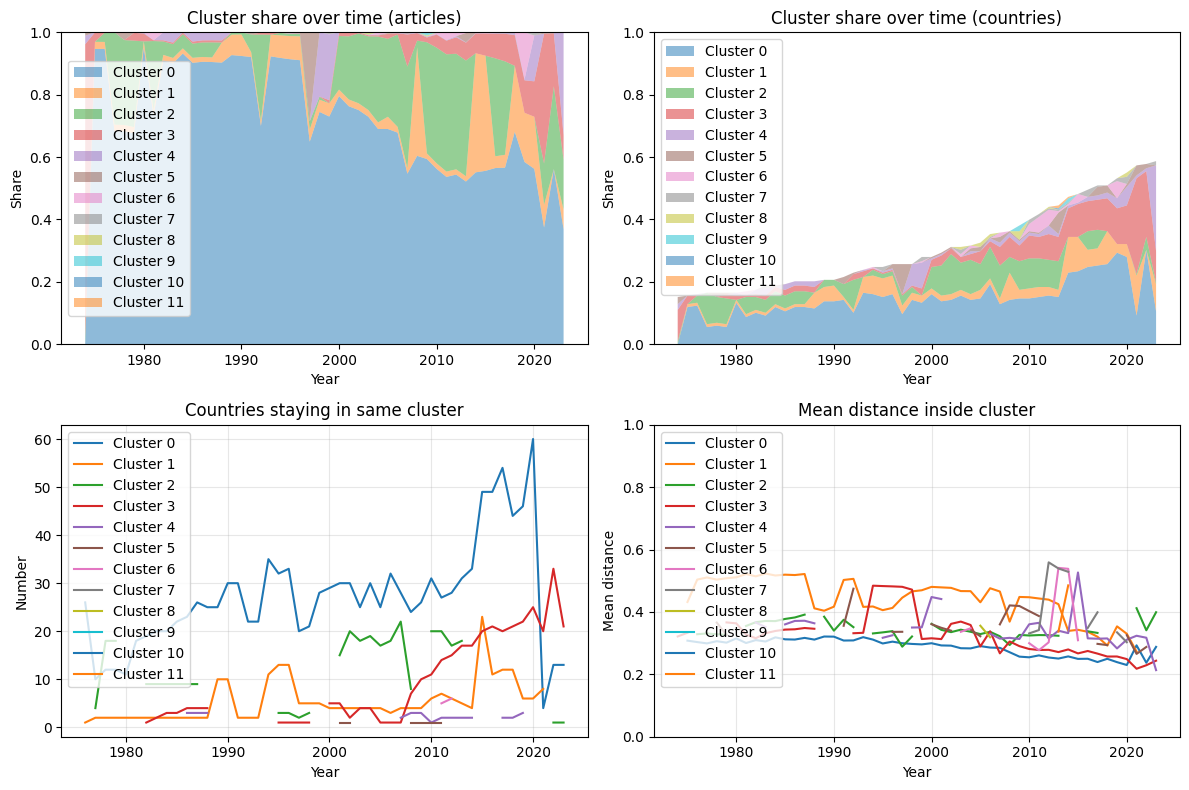

In [235]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==============================
# 1️⃣ Articles share (stacked)
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="total_articles_share"
).fillna(0)

axes[0, 0].stackplot(
    pivot.index,
    *pivot.values.T,
    labels=[f"Cluster {i}" for i in pivot.columns],
    alpha=0.5
)

axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Cluster share over time (articles)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Share")
axes[0, 0].legend()


# ==============================
# 2️⃣ Countries share (stacked)
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="countries_share"
).fillna(0)

axes[0, 1].stackplot(
    pivot.index,
    *pivot.values.T,
    labels=[f"Cluster {i}" for i in pivot.columns],
    alpha=0.5
)


axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title("Cluster share over time (countries)")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Share")
axes[0, 1].legend()


# ==============================
# 3️⃣ Number stayed
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="n_stayed"
)

for cluster in pivot.columns:
    axes[1, 0].plot(pivot.index, pivot[cluster], label=f"Cluster {cluster}")

axes[1, 0].set_title("Countries staying in same cluster")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Number")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)


# ==============================
# 4️⃣ Mean distance
# ==============================
pivot = df_stats_cluster.pivot(
    index="year", columns="cluster", values="mean_distance"
)

for cluster in pivot.columns:
    axes[1, 1].plot(pivot.index, pivot[cluster], label=f"Cluster {cluster}")
# axes[1, 1].plot(range(start_year+1, end_year+1), mean_global, label="Global")

axes[1, 1].set_title("Mean distance inside cluster")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Mean distance")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

country
AE    18
AF     1
AL    10
AM    18
AR    50
      ..
VN    22
YE     3
ZA    50
ZM     4
ZW    10
Name: cluster, Length: 129, dtype: int64

(<Figure size 1200x600 with 2 Axes>, <Axes: title={'center': ' '}>)

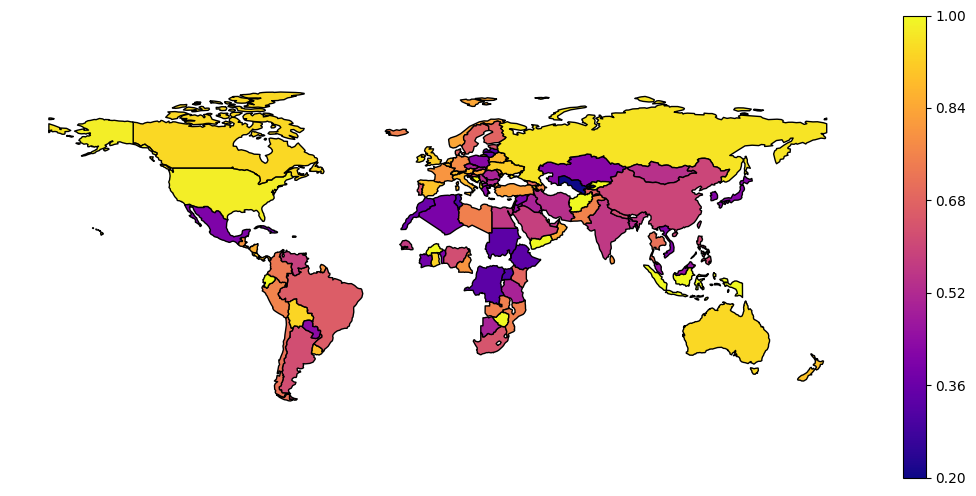

In [250]:
df_plot = (
    df_map_clean_yearly
    .groupby(["country", "cluster"], as_index=False)
    .count()
    .groupby("country")
    .year
    .max()
    .to_frame("max_years_in_cluster")
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2", how="left")
    .merge(df_map_clean_yearly.groupby("country").cluster.count().to_frame("n_years"), left_on="alpha-2", right_index=True, how="left")
    .assign(share_cluster=lambda df: df.max_years_in_cluster / df.n_years)
)
uf.plot_map_continuous(df_plot, "share_cluster")

In [237]:
year = 2020
# y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
y_labels = (
    df_map_clean_yearly
    .query("year == @year")
    .merge(df_cs_yearly.xs(year, level=1).sum(axis=1).to_frame(name="total_articles").reset_index(), on="country", how="left")
    .sort_values(["cluster", "total_articles"], ascending=[True, False])
    .country
    .to_list()
)

uf.plotly_heatmap(
    df_dist_clusters_yearly.loc[y_labels, y_labels],
    # (df_dist_clusters_yearly.loc[y_labels, y_labels] < 0.2).astype(int),
    x_labels=y_labels,
    y_labels=y_labels,
    title=f"Cluster co-membership over years (share years in different clusters) - {year}",
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
)